In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from scipy.io import loadmat


# 데이터 불러오기
data = loadmat('/content/deep_exam_data.mat')

# 데이터 내부 key 확인
print("데이터 딕셔너리 키 목록 : ", data.keys())

데이터 딕셔너리 키 목록 :  dict_keys(['__header__', '__version__', '__globals__', 'Labels', 'features'])


In [ ]:
# 총 샘플수 30개
print(data['Labels'].shape)

(30, 1)


In [ ]:
# data label값 1, 2
print(data['Labels'][:])

[[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]
 [2]]


In [ ]:
# 변수(특징), timestep, 채널수, 샘플수
print(data['features'].shape)

(62, 1001, 1, 30)


In [ ]:
# 연속형 데이터(센서, 신호)
print(data['features'][:,:,0,0])

[[ 2.84332983  2.75394333  2.67030677 ...  4.63541401  4.71104468
   4.7766862 ]
 [ 5.98642215  5.87668448  5.76371453 ...  5.11705039  5.2953535
   5.45945804]
 [ 4.35609134  4.18031374  4.00672339 ...  3.12063912  3.33133772
   3.53870503]
 ...
 [-2.38190808 -1.86413911 -1.34403446 ... -3.23983241 -3.06158468
  -2.86974528]
 [-0.21378955 -0.0237965   0.15955644 ... -1.13409695 -0.98239144
  -0.82804277]
 [-0.67775426 -0.69334054 -0.71366893 ... -0.12099433 -0.0494093
   0.01600956]]


데이터 특징
*   1001개의 timestep을 가짐
*   총 샘플수가 적어서 과적합 위험성
*   1개의 샘플당 변수 62개(변수 추출 필요)
---
# 클래스 0/1로 나누는 이진분류
Samples: patients – 15, healthy controls (HC) – 15

*   클래스 1 : patient(환자)
*   클래스 0 : HC(정상)

현재 1,2로 되어 있으므로 BinaryCrossentropy를 사용하기 위해 원핫인코딩으로 바꿔주는 작업 필요

In [ ]:
# 데이터 전처리

# (변수(특징 수), timestep, 채널수, 샘플수(배치)) -> (샘플수(배치), 타임스텝, 변수(특징 수)로 변경이 필요
X = np.squeeze(data['features']) # 1차원인 채널수 삭제
X = np.transpose(X, (2,1,0)) # 인데스를 통해서 순서 변경

# Y label값 현재 [[]] 2차원인 형태 -> 1차원 변경
# 1, 2 label 값 -> 0, 1로 변경(추후 binary crossentropy를 통한 분류를 위하여)
y = data['Labels'].flatten() -1

print(X.shape)
print(y)

(30, 1001, 62)
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


# 현재 문제 :
data sample 수가(30개) 적어서 학습 불안정 및 val 성능 떨어짐 문제
-> 데이터 증강 필요


---


# 모델 설계

*   k-fold cv를 통한 일반화 성능 높히기
*   데이터 누수를 막기 위해, k-fold 내부에서 데이터 증강
*   CNN + 양방향 LSMT을 사용하여 특징 추출 + 타임 시리즈 데이터 보존하기
*   과적합 방지를 위한 dropout + l2 규제 활용하기
*   의료 데이터의 "재현율"의 중요도를 생각하며 임계값을 낮추기(환자를 놓치지 않기 위해)






[Fold 1] 학습 진행 중
Epoch 1/100
24/24 - 3s - 118ms/step - Precision: 0.9000 - Recall: 0.7500 - accuracy: 0.8333 - loss: 0.4573 - val_Precision: 0.2500 - val_Recall: 0.3333 - val_accuracy: 0.1667 - val_loss: 0.7188
Epoch 2/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.1320 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6736
Epoch 3/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0372 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6045
Epoch 4/100
24/24 - 1s - 39ms/step - Precision: 0.9730 - Recall: 1.0000 - accuracy: 0.9861 - loss: 0.0885 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.7426
Epoch 5/100
24/24 - 1s - 24ms/step - Precision: 1.0000 - Recall: 0.9722 - accuracy: 0.9861 - loss: 0.0504 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.8809
Epoch 6/100
24/2

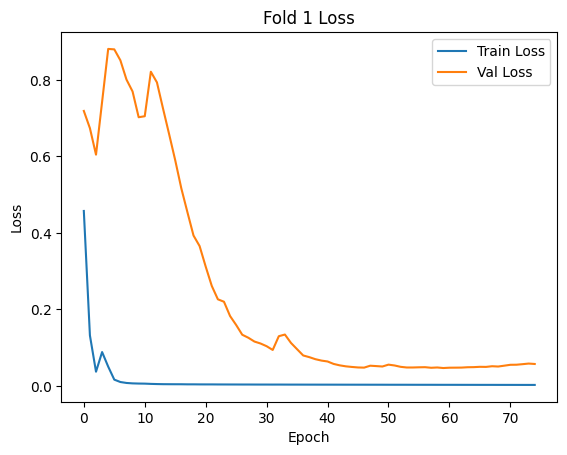


[Fold 2] 학습 진행 중
Epoch 1/100
24/24 - 3s - 119ms/step - Precision: 0.7692 - Recall: 0.8333 - accuracy: 0.7917 - loss: 0.5028 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.5657
Epoch 2/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 0.9444 - accuracy: 0.9722 - loss: 0.2094 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.4092
Epoch 3/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0767 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.3596
Epoch 4/100
24/24 - 1s - 29ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0269 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2807
Epoch 5/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0139 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2275
Epoch 6/100
24/2

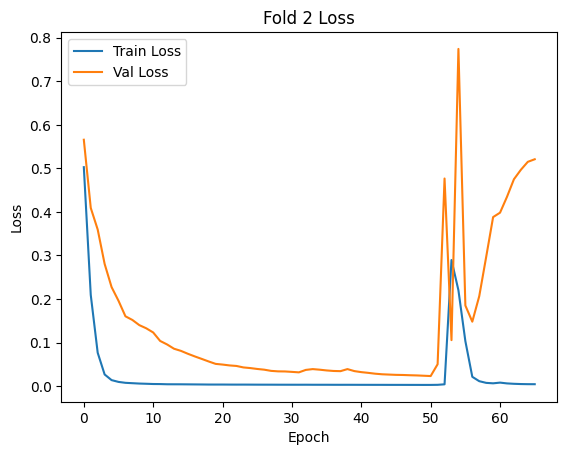


[Fold 3] 학습 진행 중
Epoch 1/100
24/24 - 3s - 118ms/step - Precision: 0.7297 - Recall: 0.7500 - accuracy: 0.7361 - loss: 0.5075 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6179
Epoch 2/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.1627 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.4895
Epoch 3/100
24/24 - 1s - 28ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0505 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.4117
Epoch 4/100
24/24 - 1s - 27ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0335 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.3233
Epoch 5/100
24/24 - 0s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0276 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.3383
Epoch 6/100
24/2

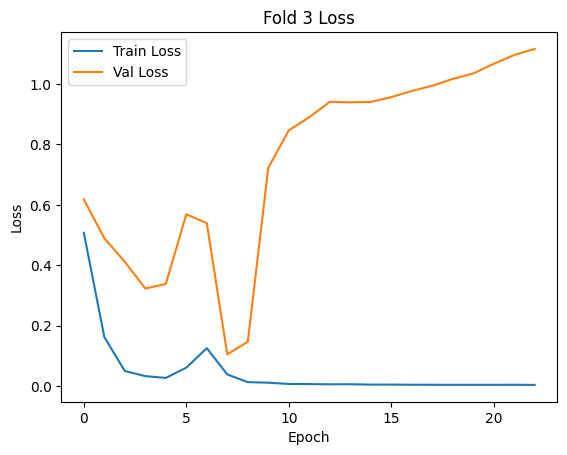


[Fold 4] 학습 진행 중
Epoch 1/100
24/24 - 3s - 121ms/step - Precision: 0.8235 - Recall: 0.7778 - accuracy: 0.8056 - loss: 0.5151 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6389
Epoch 2/100
24/24 - 0s - 20ms/step - Precision: 0.9722 - Recall: 0.9722 - accuracy: 0.9722 - loss: 0.1966 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.5757
Epoch 3/100
24/24 - 1s - 26ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0802 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.5027
Epoch 4/100
24/24 - 0s - 20ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0346 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4905
Epoch 5/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0205 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.3830
Epoch 6/100
24/2

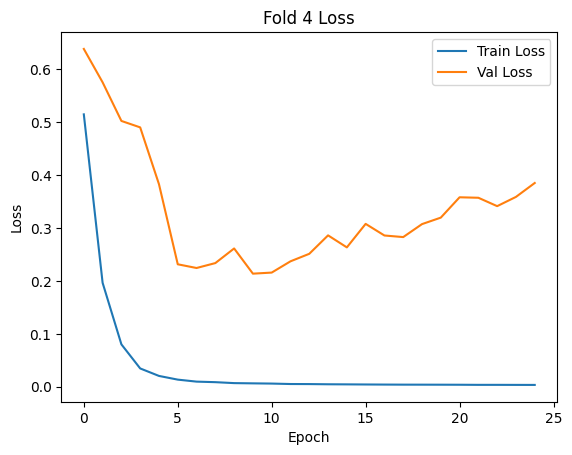


[Fold 5] 학습 진행 중
Epoch 1/100
24/24 - 3s - 140ms/step - Precision: 0.7941 - Recall: 0.7500 - accuracy: 0.7778 - loss: 0.4845 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6057
Epoch 2/100
24/24 - 1s - 22ms/step - Precision: 0.9706 - Recall: 0.9167 - accuracy: 0.9444 - loss: 0.2211 - val_Precision: 0.7500 - val_Recall: 1.0000 - val_accuracy: 0.8333 - val_loss: 0.4928
Epoch 3/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 0.9722 - accuracy: 0.9861 - loss: 0.1006 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.3430
Epoch 4/100
24/24 - 1s - 24ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0526 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.3591
Epoch 5/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0337 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.2667
Epoch 6/100
24/2

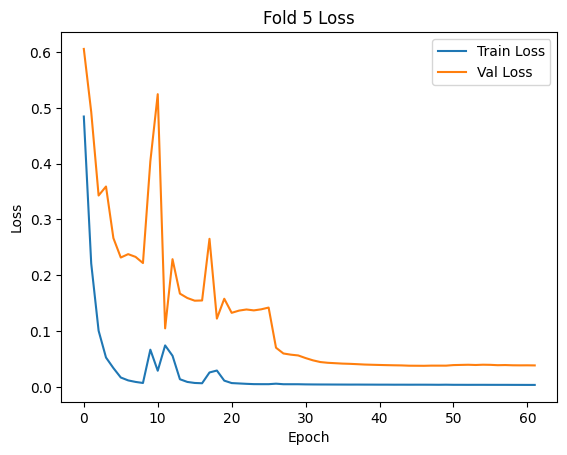

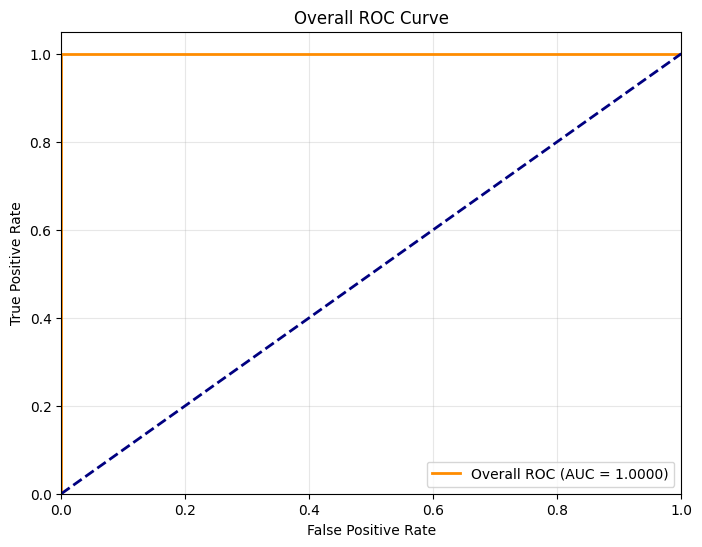


최종 평균 Accuracy: 0.9667
최종 평균 Recall: 0.9333
최종 평균 Precision: 1.0000
최종 평균 F1-Score: 0.9600
통합 전체 ROC-AUC: 1.0000


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# 5-Fold 교차 검증
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2)

# 교차검증 결과를 넣을 최종 리스트 변수
acc_results = []
recall_results = []
precision_results = []
f1_results = []

# 전체 ROC를 위해 모든 fold의 결과를 저장할 리스트
all_y_true = []
all_y_probs = []

# Cross valiation 루프
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n[Fold {fold}] 학습 진행 중")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # [데이터 누수 방지] 폴드 내부에서 스케일링 수행
    scaler = StandardScaler()
    # Train 데이터로만 fit
    X_train_shape = X_train.shape
    X_val_shape = X_val.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, 62)).reshape(X_train_shape)
    # Val 데이터는 Train의 통계치로 transform만 수행
    X_val = scaler.transform(X_val.reshape(-1, 62)).reshape(X_val_shape)

    # [데이터 증강] 리스트 함수를 사용하여 샘플 확장 후 변수명 업데이트
    X_aug_list = []
    y_aug_list = []

    for i in range(len(X_train)):
        # 원본 데이터 추가
        X_aug_list.append(X_train[i])
        y_aug_list.append(y_train[i])

        # 증강 1: Noise 추가
        np.random.seed(2)
        noise = np.random.normal(0, 0.01, X_train[i].shape)
        X_aug_list.append(X_train[i] + noise)
        y_aug_list.append(y_train[i])

        # 증강 2: Random Erasing
        # 특정 구간을 0으로 지움으로써 특정 패턴에 의존하지 못하도록 한 다음 데이터 증강
        erased = X_train[i].copy()
        start = np.random.randint(0, 800) # 0~799 중 랜덤 시작 위치
        erased[start:start+100, :] = 0 # 그 위치부터 100 timestep을 0으로 지움 (62개 변수 전부)
        X_aug_list.append(erased)
        y_aug_list.append(y_train[i])

    # 리스트를 다시 넘파이 배열로 바꾸어 변수명 덮어쓰기
    X_train = np.array(X_aug_list)
    y_train = np.array(y_aug_list)

    # 모델 설계
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape = (1001, 62)))

    # CNN
    model.add(tf.keras.layers.Conv1D(32, 5, activation = 'relu')) # 필터 개수, 커널 사이즈
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(4))
    model.add(tf.keras.layers.Conv1D(64, 3, activation = 'relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(4))

    # LSTM
    model.add(tf.keras.layers.LSTM(64))
    model.add(tf.keras.layers.Dense(1, kernel_regularizer = tf.keras.regularizers.l2(0.001), activation = 'sigmoid'))

    # 모델 컴파일
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy', 'Precision', 'Recall'])

    # 모델 학습
    callback = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 15, restore_best_weights = True)
    history = model.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = 3, epochs = 100, verbose = 2, callbacks=[callback])

    # 예측값 추출
    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # 전체 ROC를 위해 데이터 수집
    all_y_true.extend(y_val)
    all_y_probs.extend(y_pred_prob.flatten())

    # 베스트 성능 추출 (val_loss 기준)
    best_epoch = np.argmin(history.history['val_loss'])

    # 성능 평가 결과 출력
    print("\n----- Best Validation -----")
    print(f"Best Epoch       : {best_epoch + 1}")
    print(f"Train Loss / Val Loss           : {history.history['loss'][best_epoch]:.4f} / {history.history['val_loss'][best_epoch]:.4f}")
    print(f"Train Acc / Val Acc             : {history.history['accuracy'][best_epoch]:.4f} / {history.history['val_accuracy'][best_epoch]:.4f}")
    print(f"Train Precision / Val Precision : {history.history['Precision'][best_epoch]:.4f} / {history.history['val_Precision'][best_epoch]:.4f}")
    print(f"Train Recall / Val Recall       : {history.history['Recall'][best_epoch]:.4f} / {history.history['val_Recall'][best_epoch]:.4f}")

    # 학습 과정 시각화
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} Loss')
    plt.legend()
    plt.show()

    # 최종 결과 리스트에 추가 (Best Epoch 시점 값만 저장하도록)
    acc_results.append(history.history['val_accuracy'][best_epoch])
    recall_results.append(history.history['val_Recall'][best_epoch])
    precision_results.append(history.history['val_Precision'][best_epoch])
    f1_results.append(f1_score(y_val, y_pred))

# 통합 ROC 곡선 계산
fpr_total, tpr_total, _ = roc_curve(all_y_true, all_y_probs)
roc_auc_total = auc(fpr_total, tpr_total)

# 통합 ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr_total, tpr_total, color='darkorange', lw=2, label=f'Overall ROC (AUC = {roc_auc_total:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 최종 리포트
print(f"\n{'='*30}")
print(f"최종 평균 Accuracy: {np.mean(acc_results):.4f}")
print(f"최종 평균 Recall: {np.mean(recall_results):.4f}")
print(f"최종 평균 Precision: {np.mean(precision_results):.4f}")
print(f"최종 평균 F1-Score: {np.mean(f1_results):.4f}")
print(f"통합 전체 ROC-AUC: {roc_auc_total:.4f}")

In [ ]:
model.summary()

Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_168 (Conv1D)             │ (None, 997, 32)        │         9,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_168         │ (None, 997, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_168               │ (None, 249, 32)        │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_169 (Conv1D)             │ (None, 247, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_169         │ (None, 247, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_169               │ (None, 61, 64)         │             0 │
│ (MaxPooling1D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_84 (LSTM)                  │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,517 (580.15 KB)

 Trainable params: 49,441 (193.13 KB)

 Non-trainable params: 192 (768.00 B)

 Optimizer params: 98,884 (386.27 KB)

# 하단부터는 똑같은 코드입니다
# 테스트용 동일 코드입니다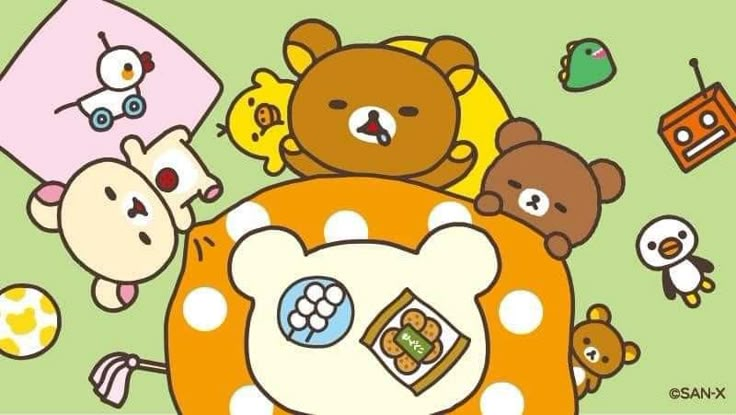




[Fold 1] 학습 진행 중
Epoch 1/100
24/24 - 3s - 137ms/step - Precision: 0.6522 - Recall: 0.8333 - accuracy: 0.6944 - loss: 0.5625 - val_Precision: 0.5000 - val_Recall: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.7195
Epoch 2/100
24/24 - 1s - 32ms/step - Precision: 1.0000 - Recall: 0.9167 - accuracy: 0.9583 - loss: 0.2590 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.6761
Epoch 3/100
24/24 - 1s - 40ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0937 - val_Precision: 0.6667 - val_Recall: 0.6667 - val_accuracy: 0.6667 - val_loss: 0.6019
Epoch 4/100
24/24 - 0s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0447 - val_Precision: 0.6667 - val_Recall: 0.6667 - val_accuracy: 0.6667 - val_loss: 0.5867
Epoch 5/100
24/24 - 1s - 22ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0199 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6076
Epoch 6/100
24/2

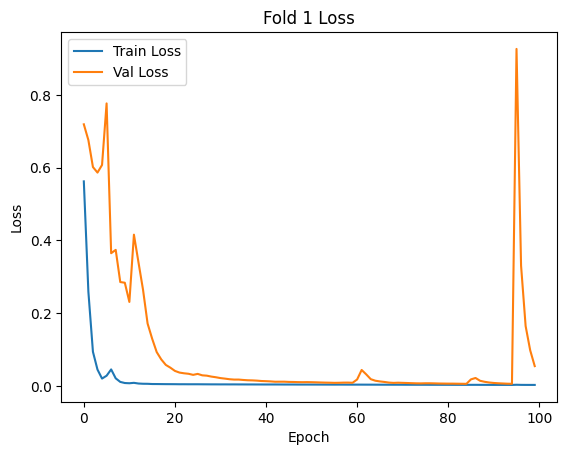


[Fold 2] 학습 진행 중
Epoch 1/100
24/24 - 3s - 135ms/step - Precision: 0.8929 - Recall: 0.6944 - accuracy: 0.8056 - loss: 0.4915 - val_Precision: 0.5000 - val_Recall: 1.0000 - val_accuracy: 0.5000 - val_loss: 0.6156
Epoch 2/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 0.9444 - accuracy: 0.9722 - loss: 0.2159 - val_Precision: 0.7500 - val_Recall: 1.0000 - val_accuracy: 0.8333 - val_loss: 0.4727
Epoch 3/100
24/24 - 0s - 20ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0647 - val_Precision: 0.5000 - val_Recall: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.5503
Epoch 4/100
24/24 - 0s - 19ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0344 - val_Precision: 0.6667 - val_Recall: 0.6667 - val_accuracy: 0.6667 - val_loss: 0.4240
Epoch 5/100
24/24 - 0s - 20ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0267 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.4893
Epoch 6/100
24/2

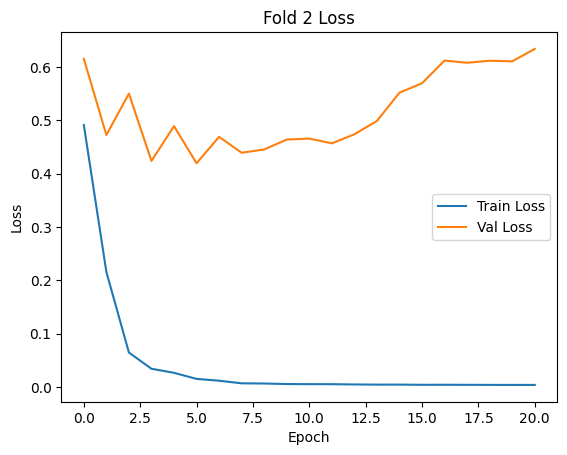


[Fold 3] 학습 진행 중
Epoch 1/100
24/24 - 3s - 116ms/step - Precision: 0.7941 - Recall: 0.7500 - accuracy: 0.7778 - loss: 0.4996 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.6042
Epoch 2/100
24/24 - 1s - 22ms/step - Precision: 1.0000 - Recall: 0.9167 - accuracy: 0.9583 - loss: 0.2031 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.5080
Epoch 3/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 0.9722 - accuracy: 0.9861 - loss: 0.0831 - val_Precision: 1.0000 - val_Recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.4234
Epoch 4/100
24/24 - 1s - 27ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0301 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.3249
Epoch 5/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0236 - val_Precision: 1.0000 - val_Recall: 0.6667 - val_accuracy: 0.8333 - val_loss: 0.2728
Epoch 6/100
24/2

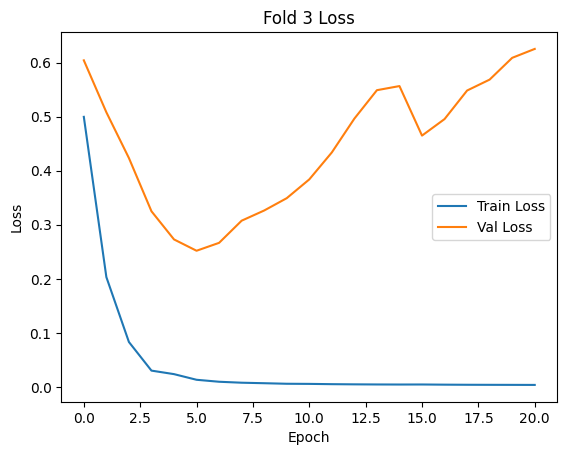


[Fold 4] 학습 진행 중
Epoch 1/100
24/24 - 3s - 123ms/step - Precision: 0.7568 - Recall: 0.7778 - accuracy: 0.7639 - loss: 0.4634 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6121
Epoch 2/100
24/24 - 0s - 21ms/step - Precision: 1.0000 - Recall: 0.9722 - accuracy: 0.9861 - loss: 0.1534 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6470
Epoch 3/100
24/24 - 1s - 22ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0610 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6037
Epoch 4/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0227 - val_Precision: 0.6000 - val_Recall: 1.0000 - val_accuracy: 0.6667 - val_loss: 0.6497
Epoch 5/100
24/24 - 1s - 24ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0136 - val_Precision: 0.5000 - val_Recall: 0.3333 - val_accuracy: 0.5000 - val_loss: 0.6339
Epoch 6/100
24/2

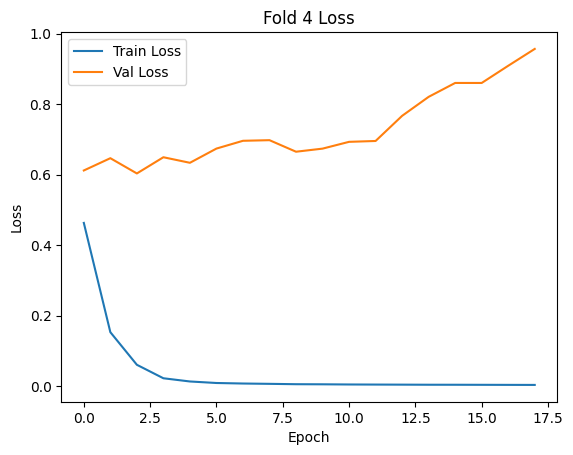


[Fold 5] 학습 진행 중
Epoch 1/100
24/24 - 3s - 138ms/step - Precision: 1.0000 - Recall: 0.6667 - accuracy: 0.8333 - loss: 0.4624 - val_Precision: 0.4000 - val_Recall: 0.6667 - val_accuracy: 0.3333 - val_loss: 0.7314
Epoch 2/100
24/24 - 1s - 28ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.1637 - val_Precision: 0.4000 - val_Recall: 0.6667 - val_accuracy: 0.3333 - val_loss: 0.7715
Epoch 3/100
24/24 - 1s - 48ms/step - Precision: 1.0000 - Recall: 0.9722 - accuracy: 0.9861 - loss: 0.0669 - val_Precision: 0.6667 - val_Recall: 0.6667 - val_accuracy: 0.6667 - val_loss: 0.6546
Epoch 4/100
24/24 - 1s - 21ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0384 - val_Precision: 0.5000 - val_Recall: 0.6667 - val_accuracy: 0.5000 - val_loss: 0.6803
Epoch 5/100
24/24 - 1s - 23ms/step - Precision: 1.0000 - Recall: 1.0000 - accuracy: 1.0000 - loss: 0.0146 - val_Precision: 0.6667 - val_Recall: 0.6667 - val_accuracy: 0.6667 - val_loss: 0.5663
Epoch 6/100
24/2

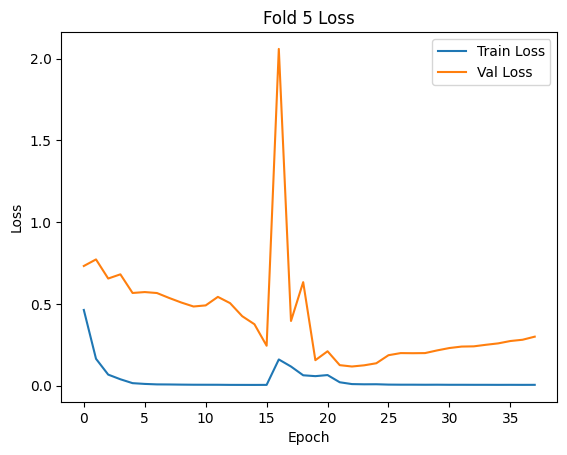

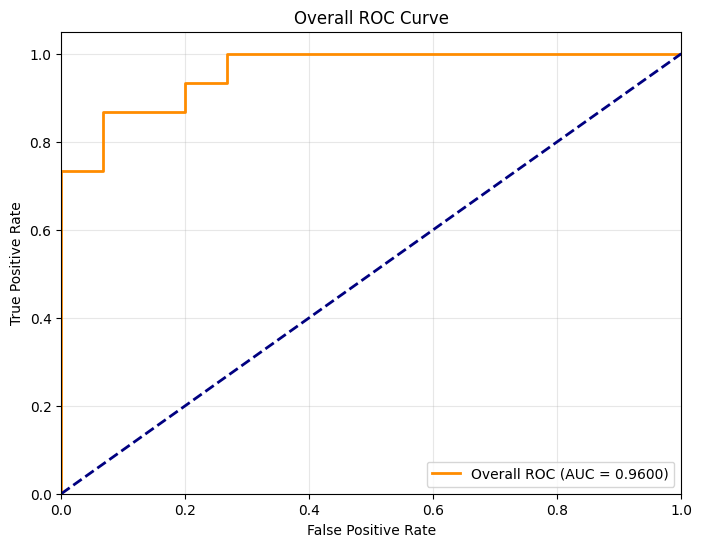


최종 평균 Accuracy: 0.8667
최종 평균 Recall: 0.9333
최종 평균 Precision: 0.8700
최종 평균 F1-Score: 0.8814
통합 전체 ROC-AUC: 0.9600


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# 5-Fold 교차 검증
skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 2)

# 교차검증 결과를 넣을 최종 리스트 변수
acc_results = []
recall_results = []
precision_results = []
f1_results = []

# 전체 ROC를 위해 모든 fold의 결과를 저장할 리스트
all_y_true = []
all_y_probs = []

# Cross valiation 루프
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n[Fold {fold}] 학습 진행 중")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # [데이터 누수 방지] 폴드 내부에서 스케일링 수행
    scaler = StandardScaler()
    # Train 데이터로만 fit
    X_train_shape = X_train.shape
    X_val_shape = X_val.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, 62)).reshape(X_train_shape)
    # Val 데이터는 Train의 통계치로 transform만 수행
    X_val = scaler.transform(X_val.reshape(-1, 62)).reshape(X_val_shape)

    # [데이터 증강] 리스트 함수를 사용하여 샘플 확장 후 변수명 업데이트
    X_aug_list = []
    y_aug_list = []

    for i in range(len(X_train)):
        # 원본 데이터 추가
        X_aug_list.append(X_train[i])
        y_aug_list.append(y_train[i])

        # 증강 1: Noise 추가
        np.random.seed(2)
        noise = np.random.normal(0, 0.01, X_train[i].shape)
        X_aug_list.append(X_train[i] + noise)
        y_aug_list.append(y_train[i])

        # 증강 2: Random Erasing
        # 특정 구간을 0으로 지움으로써 특정 패턴에 의존하지 못하도록 한 다음 데이터 증강
        erased = X_train[i].copy()
        start = np.random.randint(0, 800) # 0~799 중 랜덤 시작 위치
        erased[start:start+100, :] = 0 # 그 위치부터 100 timestep을 0으로 지움 (62개 변수 전부)
        X_aug_list.append(erased)
        y_aug_list.append(y_train[i])

    # 리스트를 다시 넘파이 배열로 바꾸어 변수명 덮어쓰기
    X_train = np.array(X_aug_list)
    y_train = np.array(y_aug_list)

    # 모델 설계
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape = (1001, 62)))

    # CNN
    model.add(tf.keras.layers.Conv1D(32, 5, activation = 'relu')) # 필터 개수, 커널 사이즈
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(4))
    model.add(tf.keras.layers.Conv1D(64, 3, activation = 'relu'))
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.MaxPooling1D(4))

    # LSTM
    model.add(tf.keras.layers.LSTM(64))
    model.add(tf.keras.layers.Dense(1, kernel_regularizer = tf.keras.regularizers.l2(0.001), activation = 'sigmoid'))

    # 모델 컴파일
    model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy', 'Precision', 'Recall'])

    # 모델 학습
    callback = tf.keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 15, restore_best_weights = True)
    history = model.fit(X_train, y_train, validation_data = (X_val, y_val), batch_size = 3, epochs = 100, verbose = 2, callbacks=[callback])

    # 예측값 추출
    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # 전체 ROC를 위해 데이터 수집
    all_y_true.extend(y_val)
    all_y_probs.extend(y_pred_prob.flatten())

    # 베스트 성능 추출 (val_loss 기준)
    best_epoch = np.argmin(history.history['val_loss'])

    # 성능 평가 결과 출력
    print("\n----- Best Validation -----")
    print(f"Best Epoch       : {best_epoch + 1}")
    print(f"Train Loss / Val Loss           : {history.history['loss'][best_epoch]:.4f} / {history.history['val_loss'][best_epoch]:.4f}")
    print(f"Train Acc / Val Acc             : {history.history['accuracy'][best_epoch]:.4f} / {history.history['val_accuracy'][best_epoch]:.4f}")
    print(f"Train Precision / Val Precision : {history.history['Precision'][best_epoch]:.4f} / {history.history['val_Precision'][best_epoch]:.4f}")
    print(f"Train Recall / Val Recall       : {history.history['Recall'][best_epoch]:.4f} / {history.history['val_Recall'][best_epoch]:.4f}")

    # 학습 과정 시각화
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Fold {fold} Loss')
    plt.legend()
    plt.show()

    # 최종 결과 리스트에 추가 (Best Epoch 시점 값만 저장하도록)
    acc_results.append(history.history['val_accuracy'][best_epoch])
    recall_results.append(history.history['val_Recall'][best_epoch])
    precision_results.append(history.history['val_Precision'][best_epoch])
    f1_results.append(f1_score(y_val, y_pred))

# 통합 ROC 곡선 계산
fpr_total, tpr_total, _ = roc_curve(all_y_true, all_y_probs)
roc_auc_total = auc(fpr_total, tpr_total)

# 통합 ROC 곡선 시각화
plt.figure(figsize=(8, 6))
plt.plot(fpr_total, tpr_total, color='darkorange', lw=2, label=f'Overall ROC (AUC = {roc_auc_total:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 최종 리포트
print(f"\n{'='*30}")
print(f"최종 평균 Accuracy: {np.mean(acc_results):.4f}")
print(f"최종 평균 Recall: {np.mean(recall_results):.4f}")
print(f"최종 평균 Precision: {np.mean(precision_results):.4f}")
print(f"최종 평균 F1-Score: {np.mean(f1_results):.4f}")
print(f"통합 전체 ROC-AUC: {roc_auc_total:.4f}")


[Fold 1] 학습 진행 중

[Fold 2] 학습 진행 중

[Fold 3] 학습 진행 중

[Fold 4] 학습 진행 중

[Fold 5] 학습 진행 중


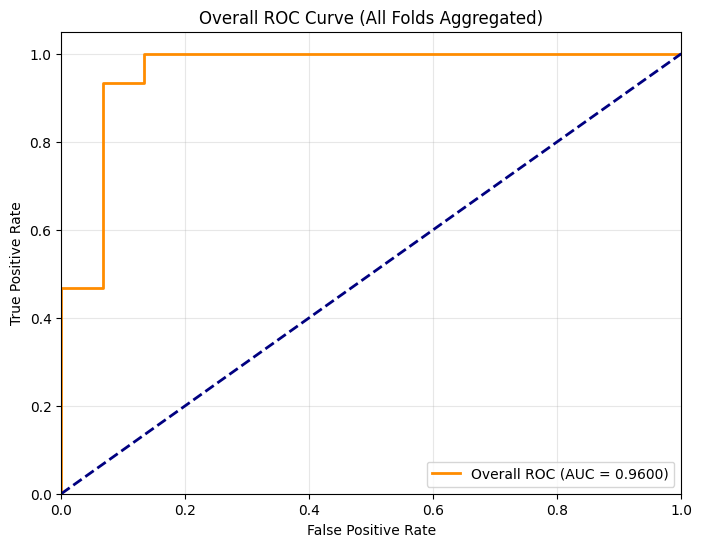


최종 평균 Accuracy: 0.9333
최종 평균 Recall: 0.9333
최종 평균 Precision: 0.9500
최종 평균 F1-Score: 0.9314
통합 전체 ROC-AUC: 0.9600


In [ ]:
import tensorflow as tf
import numpy as np
from scipy.io import loadmat
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt

# 1. 데이터 불러오기 및 전처리
data = loadmat('/content/deep_exam_data.mat')
X = np.squeeze(data['features'])
X = np.transpose(X, (2, 1, 0))  # (samples, timesteps, features)
y = data['Labels'].flatten() - 1

# 2. 5-Fold 교차 검증 설정
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

acc_results = []
recall_results = []
precision_results = []
f1_results = []
auc_results = []

# 전체 ROC를 위해 모든 fold의 결과를 저장할 리스트
all_y_true = []
all_y_probs = []

# 3. Cross Validation 루프
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n[Fold {fold}] 학습 진행 중")

    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    # 스케일링
    scaler = StandardScaler()
    X_train_shape = X_train.shape
    X_val_shape = X_val.shape
    X_train = scaler.fit_transform(X_train.reshape(-1, 62)).reshape(X_train_shape)
    X_val = scaler.transform(X_val.reshape(-1, 62)).reshape(X_val_shape)

    # 데이터 증강
    X_aug_list, y_aug_list = [], []
    for i in range(len(X_train)):
        X_aug_list.append(X_train[i])
        y_aug_list.append(y_train[i])
        np.random.seed(2)
        noise = np.random.normal(0, 0.01, X_train[i].shape)
        X_aug_list.append(X_train[i] + noise)
        y_aug_list.append(y_train[i])
        erased = X_train[i].copy()
        start = np.random.randint(0, 800)
        erased[start:start+100, :] = 0
        X_aug_list.append(erased)
        y_aug_list.append(y_train[i])

    X_train_aug = np.array(X_aug_list)
    y_train_aug = np.array(y_aug_list)

    # 4. 모델 설계
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=(1001, 62)),
        tf.keras.layers.Conv1D(32, 5, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.Conv1D(64, 3, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling1D(4),
        tf.keras.layers.LSTM(64),
        tf.keras.layers.Dense(1, kernel_regularizer=tf.keras.regularizers.l2(0.001), activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall', tf.keras.metrics.AUC(name='auc')])

    # 5. 모델 학습
    callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
    history = model.fit(X_train_aug, y_train_aug, validation_data=(X_val, y_val), batch_size=3, epochs=100, verbose=0, callbacks=[callback])

    # 6. 예측 및 성능 평가
    y_pred_prob = model.predict(X_val, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # 전체 ROC를 위해 데이터 수집
    all_y_true.extend(y_val)
    all_y_probs.extend(y_pred_prob.flatten())

    # 결과 저장
    best_val_idx = np.argmin(history.history['val_loss'])
    acc_results.append(history.history['val_accuracy'][best_val_idx])
    recall_results.append(history.history['val_Recall'][best_val_idx])
    precision_results.append(history.history['val_Precision'][best_val_idx])
    f1_results.append(f1_score(y_val, y_pred))

# 7. 전체 데이터에 대한 통합 ROC 곡선 시각화
fpr_total, tpr_total, _ = roc_curve(all_y_true, all_y_probs)
roc_auc_total = auc(fpr_total, tpr_total)

plt.figure(figsize=(8, 6))
plt.plot(fpr_total, tpr_total, color='darkorange', lw=2, label=f'Overall ROC (AUC = {roc_auc_total:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Overall ROC Curve (All Folds Aggregated)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# 최종 리포트
print(f"\n{'='*30}")
print(f"최종 평균 Accuracy: {np.mean(acc_results):.4f}")
print(f"최종 평균 Recall: {np.mean(recall_results):.4f}")
print(f"최종 평균 Precision: {np.mean(precision_results):.4f}")
print(f"최종 평균 F1-Score: {np.mean(f1_results):.4f}")
print(f"통합 전체 ROC-AUC: {roc_auc_total:.4f}")